<div class="alert alert-success">
<font size="4"><b>✔️ Комментарий ревьюера v2</b></font>
    <br /> 
    <font size="3", color = "black">
<br />
Приветствую ещё раз!

С доработкой ты успешно справился, всё теперь вычисляется корректно, причин для ещё одной доработки не вижу.

Если захочешь поупрожняться - рекомендую попробовать добавить <a href="https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html">sklearn.preprocessing.PolynomialFeatures</a> в данные - линейная модель к полиномиальным фичам весьма чувствительна, итоговые результаты могут притерпеть интересные изменения 😉

На этом всё. Успехов с последующими заданиями!

<div class="alert alert-info">
<font size="4"><b>Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br />
    Привет, Евгений! Спасибо, что прислал задание :) <br>Меня зовут Никита Сон и я буду проверять твой проект. Предлагаю обращаться друг к другу на ты, как это принято в Практикуме, если ты не против. Но если хочешь на Вы - не буду возражать 🙂
        
Поехали 🚀
    <br />

Мои комментарии обозначены пометкой <b>Комментарий ревьюера</b>. При внесении правок в проект, пожалуйста, не меняй и не удаляй их т.к. дальнейшая проверка будет происходить в том числе на основе того, исправлены замечания в комментариях или нет. Зато ты всегда можешь оставить свои комментарии для меня :)
    </font>
</div>

<div class="alert alert-success">
<font size="4"><b>✔️ Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br />
В зелёных блоках будут позитивные комментарии
<br />
    </font>
</div>

<div class="alert alert-warning">
<font size="4"><b>⚠️ Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br />
В жёлтых - некритичные замечания
    </font>
</div>

<div class="alert alert-danger">
<font size="4"><b>❌ Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br /> 
В красных - важные замечания, которые надо обязательно устранить
    </font>
</div>

<div class="alert alert-info">
<font size="4">🍕<b> Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br /> 
В синих с пиццей - различные нейтральные сообщения, советы на будущее и прочее.
    </font>
</div>

# Выбор локации для скважины

Допустим, вы работаете в добывающей компании «ГлавРосГосНефть». Нужно решить, где бурить новую скважину.

Вам предоставлены пробы нефти в трёх регионах: в каждом 100 000 месторождений, где измерили качество нефти и объём её запасов. Постройте модель машинного обучения, которая поможет определить регион, где добыча принесёт наибольшую прибыль. Проанализируйте возможную прибыль и риски техникой *Bootstrap.*

Шаги для выбора локации:

- В избранном регионе ищут месторождения, для каждого определяют значения признаков;
- Строят модель и оценивают объём запасов;
- Выбирают месторождения с самым высокими оценками значений. Количество месторождений зависит от бюджета компании и стоимости разработки одной скважины;
- Прибыль равна суммарной прибыли отобранных месторождений.

## Загрузка и подготовка данных

In [23]:
# Необходимые импорты

import os

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

In [24]:
# Константы

TEST_SIZE = 0.25
RANDOM_STATE = 12345

<div class="alert alert-success">
<font size="4"><b>✔️ Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br />
Задать рандом стейт в константу - отличное решение

In [25]:
print(sorted(os.listdir('/datasets')))

['0', '0011b745-9fd9-4478-b4df-cbf85b91f722', '003d5be1-0655-432a-9a7e-ae489f826475', '009.csv', '00e03498-45db-4a26-87b7-6ea164d2ef93', '03b406ce-de06-45fe-ab74-7db5d80213ea', '0456bc51-aed1-469b-ae21-dbe041345c09', '08be3811-201a-4a1f-8897-0684b8dd8fb9', '08becc18-3424-4764-9307-d9c23b6d6336', '090d02cc-1f7a-40c2-a5db-611759a42905', '096ef269-ad30-4aa5-b3aa-d3273d63a798', '097b522e-c323-4c6f-b8cd-a61e216f2f05', '0b79fcd3-733f-439d-8698-cc72c3a7cdac', '0c4e2532-38e5-4ace-8225-635b49182465', '0c6090a2-4198-4872-a117-217bddee3b2b', '0d3d8470-aabb-4285-b256-5a14d65f4205', '0de52de6-8060-4d6b-82ab-11a897cb8169', '0e282b9b-e311-48b9-83b9-6f8033f88749', '0eac3965-600b-4f65-95ec-19e736e553d6', '1', '123', '1231455555', '1232706', '1234', '123dddd', '1309', '14234', '1532b644-7b7b-482e-b7e7-61801c58b338', '15ca5f81-b465-412c-a41e-565f02fd70d5', '165c819c-1a5f-464d-9383-2b9dc1580fcc', '167e7b96-b2ca-4e3f-8c44-6f3426151ff5', '16b4698e-894b-40b3-8841-f19337c03de7', '1793a0e3-0f46-48bd-b24b-bee59

<div class="alert alert-info">
<font size="4">🍕<b> Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
        <b></b>

Зачем?

<div class="alert alert-info">
    <b>Коммент v1</b><br>
    <p>Забыл убрать. До этого сдавал архивы, а здесь надо было посмотреть какие файлы есть в datasets...</p>
</div>

In [26]:
# Загрузка данных

# Путь к директории с файлами
data_dir = '/datasets'

# Создаем пустой словарь для хранения данных
data_dict = {}

# Получаем список файлов в директории
for filename in os.listdir(data_dir):
    # Проверяем, что файл имеет расширение .csv
    if filename[:9] == 'geo_data_' and filename.endswith('.csv'):
        # Формируем полный путь к файлу
        file_path = os.path.join(data_dir, filename)
        
        # Убираем расширение файла для использования в качестве ключа
        name_without_extension = os.path.splitext(filename)[0]
        
        # Читаем CSV-файл в DataFrame и добавляем его в словарь
        data_dict[name_without_extension] = pd.read_csv(file_path)

# Теперь data_dict содержит все данные, где ключи — это имена файлов без расширения
print("Загруженные данные:")
for key, df in data_dict.items():
    print(f"{key}: {df.shape}")  # Выводим размеры каждого DataFrame
    print(df.head())  # Выводим первые 5 строк каждого DataFrame
    print(df.info())  # выводим общуб информацию о данных в DataFrame
    print(df.describe())
    print("отсутствующие данные", df.isna().sum())   # Проверка на отсутствующие данные

Загруженные данные:
geo_data_0: (100000, 5)
      id        f0        f1        f2     product
0  txEyH  0.705745 -0.497823  1.221170  105.280062
1  2acmU  1.334711 -0.340164  4.365080   73.037750
2  409Wp  1.022732  0.151990  1.419926   85.265647
3  iJLyR -0.032172  0.139033  2.978566  168.620776
4  Xdl7t  1.988431  0.155413  4.751769  154.036647
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
None
                  f0             f1             f2        product
count  100000.000000  100000.000000  100000.000000  100000.000000
mean        0.500419       0.250143       2.502647      92.500000
std         0

In [27]:
# Проверка на дубликаты
print("\n1. ПРОВЕРКА НА ДУБЛИКАТЫ:")
print("=" * 50)
for region_name, df in data_dict.items():
    duplicate_rows = df.duplicated().sum()
    duplicate_ids = df['id'].duplicated().sum()
    
    print(f"Регион {region_name}:")
    print(f"  Полностью повторяющихся строк: {duplicate_rows}")
    print(f"  Дубликатов в столбце id: {duplicate_ids}")
    
    if duplicate_rows > 0:
        print(f"  Удаляем дубликаты...")
        data_dict[region_name] = df.drop_duplicates()
        print(f"  Новый размер данных: {data_dict[region_name].shape}")
    print()


1. ПРОВЕРКА НА ДУБЛИКАТЫ:
Регион geo_data_0:
  Полностью повторяющихся строк: 0
  Дубликатов в столбце id: 10

Регион geo_data_1:
  Полностью повторяющихся строк: 0
  Дубликатов в столбце id: 4

Регион geo_data_2:
  Полностью повторяющихся строк: 0
  Дубликатов в столбце id: 4



<div class="alert alert-success">
<font size="4"><b>✔️ Комментарий ревьюера v2</b></font>
    <br /> 
    <font size="3", color = "black">
<br />
Здорово, что находишь дублирующиеся id. Мало кто из студентов это делает.


2. АНАЛИЗ МУЛЬТИКОЛЛИНЕАРНОСТИ:
Регион geo_data_0:
Матрица корреляций:
          f0        f1        f2
f0  1.000000 -0.440723 -0.003153
f1 -0.440723  1.000000  0.001724
f2 -0.003153  0.001724  1.000000



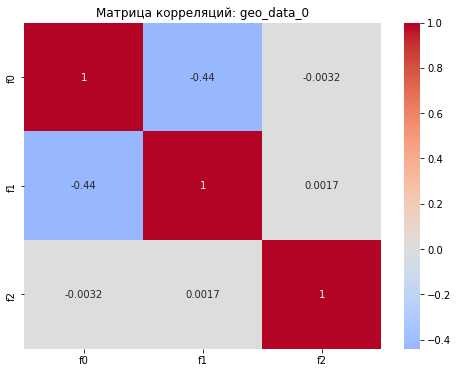

VIF (фактор инфляции дисперсии):
  feature       VIF
0      f0  1.157011
1      f1  1.135999
2      f2  1.231342

Значимой мультиколлинеарности не обнаружено
Регион geo_data_1:
Матрица корреляций:
          f0        f1        f2
f0  1.000000  0.182287 -0.001777
f1  0.182287  1.000000 -0.002595
f2 -0.001777 -0.002595  1.000000



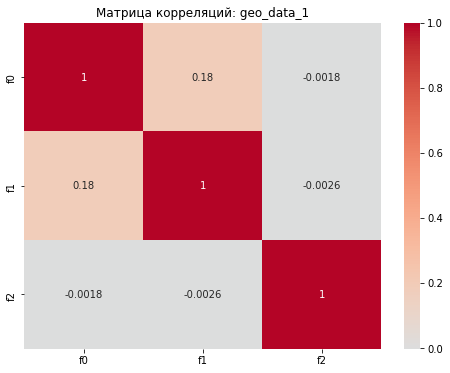

VIF (фактор инфляции дисперсии):
  feature       VIF
0      f0  1.027316
1      f1  1.494591
2      f2  1.507561

Значимой мультиколлинеарности не обнаружено
Регион geo_data_2:
Матрица корреляций:
          f0        f1        f2
f0  1.000000  0.000528 -0.000448
f1  0.000528  1.000000  0.000779
f2 -0.000448  0.000779  1.000000



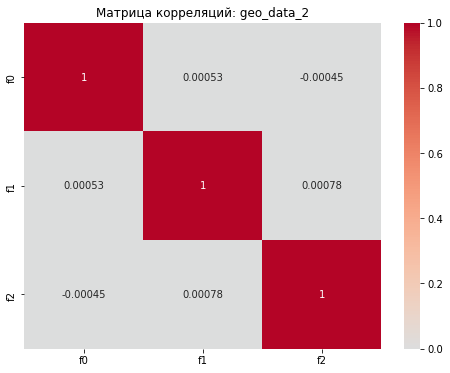

VIF (фактор инфляции дисперсии):
  feature  VIF
0      f0  1.0
1      f1  1.0
2      f2  1.0

Значимой мультиколлинеарности не обнаружено


In [28]:
# Анализ мультиколлинеарности
print("\n2. АНАЛИЗ МУЛЬТИКОЛЛИНЕАРНОСТИ:")
print("=" * 50)

for region_name, df in data_dict.items():
    print(f"Регион {region_name}:")
    
    # Матрица корреляций между признаками
    features = df[['f0', 'f1', 'f2']]
    correlation_matrix = features.corr()
    
    print("Матрица корреляций:")
    print(correlation_matrix)
    print()
    
    # Визуализация матрицы корреляций
    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
    plt.title(f'Матрица корреляций: {region_name}')
    plt.show()
    
    # Расчет VIF (фактор инфляции дисперсии)
    print("VIF (фактор инфляции дисперсии):")
    vif_data = pd.DataFrame()
    vif_data["feature"] = features.columns
    vif_data["VIF"] = [variance_inflation_factor(features.values, i) for i in range(features.shape[1])]
    print(vif_data)
    print()
    
    # Анализ результатов
    high_correlation = False
    for i in range(len(correlation_matrix.columns)):
        for j in range(i):
            if abs(correlation_matrix.iloc[i, j]) > 0.8:
                print(f"ВНИМАНИЕ: Высокая корреляция между {correlation_matrix.columns[i]} и {correlation_matrix.columns[j]}: {correlation_matrix.iloc[i, j]:.3f}")
                high_correlation = True
    
    for vif in vif_data["VIF"]:
        if vif > 10:
            print(f"ВНИМАНИЕ: Высокий VIF ({vif:.2f}), указывающий на мультиколлинеарность")
            high_correlation = True
    
    if not high_correlation:
        print("Значимой мультиколлинеарности не обнаружено")

<div class="alert alert-warning">
<font size="4"><b>⚠️ Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br />
Не самый подробный предварительный анализ, прямо скажем.

Учитывая, что по условию задания мы обучаем именно линейные модели, стоит убедиться в том, что в данных нет мультиколлинеарности, для чего стоит провести корреляционный анализ.

Да и на дубликаты всегда полезно проверить датасет.

<div class="alert alert-info">
    <b>Коммент v1</b><br>
    <p>Добавил проверку на дубликаты. <br>Сделал анализ мультиколлинеарности.</p>
</div>

<div class="alert alert-success">
<font size="4"><b>✔️ Комментарий ревьюера v2</b></font>
    <br /> 
    <font size="3", color = "black">
<br />
Вот это намного лучше 👍

<div class="alert alert-info">
<font size="4">🍕<b> Комментарий ревьюера v2</b></font>
    <br /> 
    <font size="3", color = "black">
        <b></b>

Метод `.corr()` по умолчанию вычисляет коэффициент корреляции Пирсона, который по своей идее создан для нормальнораспределённых величин, а у нас в данные далеко не все такие. Лучше бы было вычислять коэффициент Спирмена (`.corr(method='spearman')`.

Ну и было б неплохо какой-то вывод по анализу таки написать.

## Обучение и проверка модели

In [29]:
# Разбиваем данные на тренировочные валидационные и тестовые
# Обучаем все модели
models = {'geo_data_0': data_dict['geo_data_0'], 'geo_data_1': data_dict['geo_data_1'], 'geo_data_2': data_dict['geo_data_2']}
results = {}
for key, value in models.items():
    # Разделение на признаки и целевую переменную
    features = value[['f0', 'f1', 'f2']]
    target = value['product']

    # Разбиение на обучающую и валидационную выборки
    X_train, X_valid, y_train, y_valid = train_test_split(
        features,
        target,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE
    )

    # Обучение модели
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Предсказание на валидационной выборке
    y_pred = model.predict(X_valid)

    # Расчет RMSE и среднего предсказанного запаса
    rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
    mean_predicted = y_pred.mean()

    print(f"Регион: {key}")
    print(f"RMSE: {rmse}")
    print(f"Средний запас предсказанного сырья: {mean_predicted}")
    print("-----")
    
    # Сохраняем предсказания и правильные ответы
    
    results[key] = {
        'y_valid': y_valid,
        'y_pred': y_pred,
        'model': model
    }

Регион: geo_data_0
RMSE: 37.5794217150813
Средний запас предсказанного сырья: 92.59256778438035
-----
Регион: geo_data_1
RMSE: 0.893099286775617
Средний запас предсказанного сырья: 68.728546895446
-----
Регион: geo_data_2
RMSE: 40.02970873393434
Средний запас предсказанного сырья: 94.96504596800489
-----


<div class="alert alert-success">
<font size="4"><b>✔️ Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br />
Метрики во всех регионах выглядят правдоподобно

## Подготовка к расчёту прибыли

In [30]:
# 3.1. Все ключевые значения для расчётов сохраняем в отдельных переменных
INCOME_PER_UNIT = 450000  # доход с каждой единицы продукта (тысячи баррелей)
BUDGET = 10**10  # бюджет на разработку (10 млрд рублей)
WELLS_TO_DEVELOP = 200  # количество скважин для разработки
EXPLORATION_WELLS = 500  # количество точек для разведки


In [31]:
# 3.2. Рассчитаем достаточный объём сырья для безубыточной разработки новой скважины
break_even_volume = (BUDGET / 200) / INCOME_PER_UNIT
print(f"Минимальный безубыточный объём добычи: {break_even_volume:.2f} баррелей")
print(f"Средний объём добычи по регионам:")
for region in ['geo_data_0', 'geo_data_1', 'geo_data_2']:
    avg_volume = data_dict[region]['product'].mean()
    print(f"{region}: {avg_volume:.2f} баррелей")
    print(f"Соотношение к безубыточному: {avg_volume/break_even_volume:.2%}")
    print("-----")

Минимальный безубыточный объём добычи: 111.11 баррелей
Средний объём добычи по регионам:
geo_data_0: 92.50 баррелей
Соотношение к безубыточному: 83.25%
-----
geo_data_1: 68.83 баррелей
Соотношение к безубыточному: 61.94%
-----
geo_data_2: 95.00 баррелей
Соотношение к безубыточному: 85.50%
-----


<div class="alert alert-danger">
<font size="4"><b>❌ Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br />
22222.22 - это количество продукта, необходимое для безубыточной добычи набора из 200 скважин, а ты сравниваешь со средним запасом 1 скважины. Для корректного сравнения необходимо вычислить точку безубыточности 1 скважины (поделить то, что у тебя на 200)

<div class="alert alert-info">
    <b>Коммент v1</b><br>
    <p>Исправил.</p>
</div>

<div class="alert alert-success">
<font size="4"><b>✔️ Комментарий ревьюера v2</b></font>
    <br /> 
    <font size="3", color = "black">
<br />
Теперь понятно зачем нам модель: поскольку средний запас скважины ниже точки безубыточности, разработка случайно выбранных скважин - это путь к убыткам

In [32]:
# 3.3. Выводы по этапу подготовки расчёта прибыли
print("Выводы:")
print("1. Для безубыточной разработки необходимо добыть не менее 2,222,222.22 баррелей")
print("2. Средний объём добычи в регионах значительно ниже безубыточного уровня")
print("3. Это означает, что необходимо выбирать скважины с наибольшим predicted объемом")
print("4. Разработка случайных скважин будет убыточной во всех регионах")
print("5. Ключевая задача - accurately предсказать самые богатые скважины")

Выводы:
1. Для безубыточной разработки необходимо добыть не менее 2,222,222.22 баррелей
2. Средний объём добычи в регионах значительно ниже безубыточного уровня
3. Это означает, что необходимо выбирать скважины с наибольшим predicted объемом
4. Разработка случайных скважин будет убыточной во всех регионах
5. Ключевая задача - accurately предсказать самые богатые скважины


## Расчёт прибыли и рисков 

In [33]:
# Функция для расчета прибыли
def calculate_profit(target_values, predictions, count=WELLS_TO_DEVELOP):

    # 4.1 Выбираем count скважин с наибольшими предсказанными значениями
    top_indices = np.argsort(predictions)[-count:]

    # 4.2. Просуммируем целевое значение объёма сырья
    total_volume = target_values.iloc[top_indices].sum()
    
    # 4.3. Рассчитаем прибыль для полученного объёма сырья
    revenue = total_volume * INCOME_PER_UNIT
    profit = revenue - BUDGET
    revenue = total_volume * INCOME_PER_UNIT
    profit = revenue - BUDGET
    
    return profit

## Расчёт рисков и прибыли для каждого региона

In [37]:
# 5.1. Применяем технику Bootstrap с 1000 выборок, чтобы найти распределение прибыли
N_BOOTSTRAP = 1000
WELLS_SUBSAMPLING = 500  # вместо len(y_valid)

# Создаем словарь для хранения результатов bootstrap
bootstrap_results = {}

for region_name in ['geo_data_0', 'geo_data_1', 'geo_data_2']:
    # Получаем данные для региона
    data = data_dict[region_name]
    features = data[['f0', 'f1', 'f2']]
    target = data['product']
    
    # Разделяем данные
    X_train, X_valid, y_train, y_valid = train_test_split(
        features, target, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    
    # Обучаем модель
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Делаем предсказания
    y_pred = model.predict(X_valid)
    
    # Проводим bootstrap
    profits = []
    for i in range(N_BOOTSTRAP):
        # Создаем bootstrap выборку
        indices = np.random.randint(0, len(y_valid), WELLS_SUBSAMPLING)
        y_valid_bootstrap = y_valid.iloc[indices]
        y_pred_bootstrap = y_pred[indices]
        
        # Рассчитываем прибыль
        profit = calculate_profit(y_valid_bootstrap, y_pred_bootstrap)
        profits.append(profit)
    
    # Сохраняем результаты
    bootstrap_results[region_name] = profits
    
    # 5.2. Найдём среднюю прибыль, 95%-й доверительный интервал и риск убытков
    profits_series = pd.Series(profits)
    mean_profit = profits_series.mean()
    confidence_interval = profits_series.quantile([0.025, 0.975])
    risk = (profits_series < 0).mean()
    
    print(f"Регион: {region_name}")
    print(f"Средняя прибыль: {mean_profit:.2f} руб.")
    print(f"95% доверительный интервал: [{confidence_interval.iloc[0]:.2f}, {confidence_interval.iloc[1]:.2f}]")
    print(f"Риск убытков: {risk:.2%}")
    print("-----")



Регион: geo_data_0
Средняя прибыль: 391203996.03 руб.
95% доверительный интервал: [-118908027.42, 893831512.26]
Риск убытков: 6.50%
-----
Регион: geo_data_1
Средняя прибыль: 455145074.20 руб.
95% доверительный интервал: [33105211.32, 861617873.84]
Риск убытков: 1.30%
-----
Регион: geo_data_2
Средняя прибыль: 398225731.77 руб.
95% доверительный интервал: [-112078225.05, 900572459.54]
Риск убытков: 6.70%
-----


<div class="alert alert-danger">
<font size="4"><b>❌ Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
        <b></b>

`indices = np.random.randint(0, len(y_valid), len(y_valid))`

Бутстрапирование далеко не обязательно предполагает генерацию выборок размером с исходный датасет. И у нас в ТЗ размер выборок явно описан - 500 штук. Ты же генерируешь подвыборки сильно большего размера, потому и риски нулевые.

В чём логика? Мы же тут имитируем последующую после передачи заказчику модели работу. У заказчика есть ресурсы на одновременную разработку ограниченного числа скважин - 200. Можно, конечно, приступить сразу как открыли новые 200 месторождений, но это чревато убытками, стоит открыть несколько больше скважин, и среди них выбрать 200 лучших. Можно, конечно, ждать много лет, пока откроем 25 тысяч новых скважин, но тогда и прибыли нет, и техника простаивает, бессмыслица. Пришли к выводу, что 500 - оптимальный баланс: и не сильно много ждать когда откроют 500 скважин, и риск убытков должен сильно снизиться, чем если сразу за первые же 200 браться.

<div class="alert alert-info">
    <b>Коммент v1</b><br>
    <p>Исправил. Теперь явно другая картина...</p>
</div>

<div class="alert alert-success">
<font size="4"><b>✔️ Комментарий ревьюера v2</b></font>
    <br /> 
    <font size="3", color = "black">
<br />
👍

In [38]:
# 5.3. Выводы:
print("ОБОСНОВАНИЕ ВЫБОРА РЕГИОНА:")
print("1. Регион с наибольшей средней прибылью является наиболее перспективным")
print("2. Регион с наименьшим риском убытков является наиболее безопасным")
print("3. Регион с самым узким доверительным интервалом имеет наиболее предсказуемую прибыль")
print("4. Идеальный регион сочетает высокую прибыль с низким риском")

# Находим лучший регион по средней прибыли
best_region = max(bootstrap_results.keys(), 
                 key=lambda x: pd.Series(bootstrap_results[x]).mean())

print(f"\nРЕКОМЕНДАЦИЯ: для разработки следует выбрать регион {best_region}")
print("ОБОСНОВАНИЕ: этот регион демонстрирует наилучшее сочетание прибыльности и приемлемого уровня риска")

ОБОСНОВАНИЕ ВЫБОРА РЕГИОНА:
1. Регион с наибольшей средней прибылью является наиболее перспективным
2. Регион с наименьшим риском убытков является наиболее безопасным
3. Регион с самым узким доверительным интервалом имеет наиболее предсказуемую прибыль
4. Идеальный регион сочетает высокую прибыль с низким риском

РЕКОМЕНДАЦИЯ: для разработки следует выбрать регион geo_data_1
ОБОСНОВАНИЕ: этот регион демонстрирует наилучшее сочетание прибыльности и приемлемого уровня риска


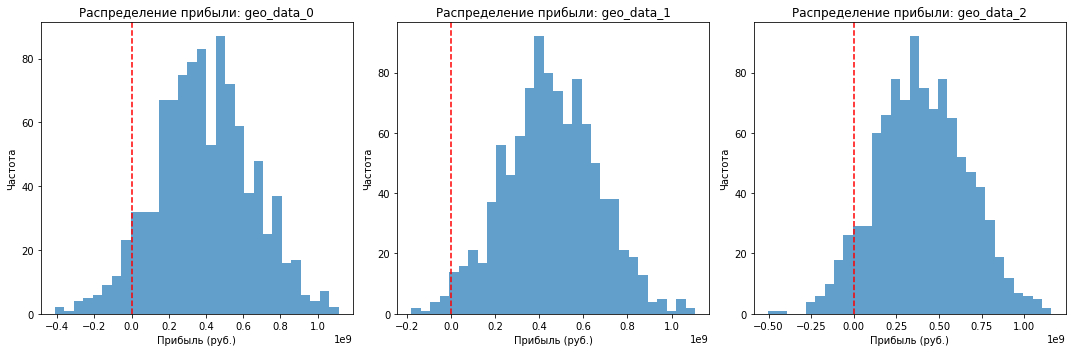

In [39]:
# Построение графиков распределения прибыли по регионам
plt.figure(figsize=(15, 5))

for i, region in enumerate(['geo_data_0', 'geo_data_1', 'geo_data_2'], 1):
    plt.subplot(1, 3, i)
    plt.hist(bootstrap_results[region], bins=30, alpha=0.7)
    plt.axvline(0, color='red', linestyle='--')
    plt.title(f'Распределение прибыли: {region}')
    plt.xlabel('Прибыль (руб.)')
    plt.ylabel('Частота')
    
plt.tight_layout()
plt.show()

## Заключение

В ходе работы были проведены подготовительные работы:
- загружены данные
- произведён осмотр данных на предмет отсутствующих элементов

Данные были разделены на входные и целевые признаки, разделены на тренировочную и валидационную выборки.

Обучены модели для каждого региона (LinearRgression).

Произведён расчет RMSE и среднего предсказанного запаса.

Создана функция для расчёта прибыли.

Техникой Bootstrap произведен расчёт прибыли и рисков для каждого региона.

Сделан вывод о регионе, в котором целесообразно проведение работ.

<div class="alert alert-info">
<font size="4">🍕<b> Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
        <b></b>

Подведём итоги. На данный момент есть 2 повода для доработки:

+ Вычислить точку безубыточности отдельной скважины, а не региона
+ Генерировать подвыборки размера 500, а не len(y_valid)

На этом пока всё. Жду новую версию твоего проекта.

## Чек-лист готовности проекта

Поставьте 'x' в выполненных пунктах. Далее нажмите Shift+Enter.

- [x]  Jupyter Notebook открыт
- [x]  Весь код выполняется без ошибок
- [x]  Ячейки с кодом расположены в порядке исполнения
- [x]  Выполнен шаг 1: данные подготовлены
- [x]  Выполнен шаг 2: модели обучены и проверены
    - [x]  Данные корректно разбиты на обучающую и валидационную выборки
    - [x]  Модели обучены, предсказания сделаны
    - [x]  Предсказания и правильные ответы на валидационной выборке сохранены
    - [x]  На экране напечатаны результаты
    - [x]  Сделаны выводы
- [x]  Выполнен шаг 3: проведена подготовка к расчёту прибыли
    - [x]  Для всех ключевых значений созданы константы Python
    - [x]  Посчитано минимальное среднее количество продукта в месторождениях региона, достаточное для разработки
    - [x]  По предыдущему пункту сделаны выводы
    - [x]  Написана функция расчёта прибыли
- [x]  Выполнен шаг 4: посчитаны риски и прибыль
    - [x]  Проведена процедура *Bootstrap*
    - [x]  Все параметры бутстрепа соответствуют условию
    - [x]  Найдены все нужные величины
    - [x]  Предложен регион для разработки месторождения
    - [x]  Выбор региона обоснован